# scWAT Xenium slide QC summary

## Goal

Combine exactly four validated region bundles from one run label and execution mode. The summary compares two sections within each of `Mouse_1` and `Mouse_2` without treating cells as biological replicates and without inventing a left/right factor.


## Setup

HPC paths are defaults. Local validation injects D-drive paths and `LOCAL_SUBSET`. No package installation or writes outside `adipose_analysis` are permitted.


In [5]:
EXECUTION_MODE <- toupper(Sys.getenv("SCWAT_QC_MODE", "FULL_HPC"))
PROJECT_ROOT <- Sys.getenv("SCWAT_PROJECT_ROOT", "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium")
PIPELINE_REPO <- Sys.getenv("SCWAT_PIPELINE_REPO", file.path(PROJECT_ROOT, "adipose_analysis_B2", "YNH_Xenium_scWAT"))
RUN_LABEL <- Sys.getenv("SCWAT_RUN_LABEL", "scwat_qc_hpc")
RUN_ROOT <- Sys.getenv("SCWAT_RUN_ROOT", file.path(PROJECT_ROOT, "adipose_analysis_B2", "scwat_qc_outputs", RUN_LABEL))
TEMP_ROOT <- Sys.getenv("SCWAT_TEMP_ROOT", file.path(PROJECT_ROOT, "adipose_analysis_B2", "tmp", RUN_LABEL))
dir.create(TEMP_ROOT, recursive = TRUE, showWarnings = FALSE)
Sys.setenv(TMPDIR = TEMP_ROOT, TMP = TEMP_ROOT, TEMP = TEMP_ROOT)
source(file.path(PIPELINE_REPO, "R", "source.R"))
regions <- expected_scwat_regions()


## Inputs and integrity

Require Region_1 through Region_4, reject missing or duplicate regions and mixed run labels or modes, then reload every saved sparse object and table.


In [2]:
manifest <- utils::read.delim(file.path(PIPELINE_REPO, "config", "scwat_sample_manifest.tsv"), check.names = FALSE)
manifest_check <- validate_sample_manifest(manifest, regions)
stopifnot(isTRUE(manifest_check$valid))
slide_data <- read_scwat_slide_qc_outputs(RUN_ROOT, expected_regions = regions, run_label = RUN_LABEL, execution_mode = EXECUTION_MODE)
stopifnot(identical(slide_data$coverage$region_id, regions))


Loading required namespace: Matrix



## Cell QC

Summarize fixed-bound pass fractions and review flags. `primary_include` is never redefined at slide level. Region readiness is derived from current evidence rather than inherited anchor or sensitivity labels.


In [3]:
slide_summary <- summarise_slide_qc(slide_data)
mouse_summary <- summarise_scwat_mouse_sections(slide_summary$section_summary, manifest)
mouse_summary$within_mouse
mouse_summary$mouse_summary


region_id,mouse_id,section_id,input_cells,core_qc_pass,core_qc_fail,review_flagged,nucleus_missing,multiple_nuclei,segmentation_multiplet,area_outlier,high_control,cells_deleted,run_label,execution_mode,core_pass_fraction,review_fraction
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>
Region_1,Mouse_1,62308,92044,91218,826,4448,1177,1506,1605,1066,0,0,scwat_qc_hpc,FULL_HPC,0.9910260,0.04832471
Region_2,Mouse_1,62309,66787,65542,1245,3369,854,766,814,653,1,0,scwat_qc_hpc,FULL_HPC,0.9813586,0.05044395
Region_3,Mouse_2,62310,75655,74562,1093,4613,1481,1009,1050,1191,2,0,scwat_qc_hpc,FULL_HPC,0.9855528,0.06097416
Region_4,Mouse_2,62311,50439,49217,1222,2517,595,579,599,253,4,0,scwat_qc_hpc,FULL_HPC,0.9757727,0.04990186


mouse_id,input_cells,core_qc_pass,core_pass_fraction,n_sections
<chr>,<dbl>,<dbl>,<dbl>,<int>
Mouse_1,79415.5,78380.0,0.9861923,2
Mouse_2,63047.0,61889.5,0.9806628,2


## Outputs and checks

Save combined tables, descriptive within-mouse and mouse-level summaries, readiness gates, figures, session information, and a reloadable slide object.


In [6]:
summary_output_dir <- file.path(RUN_ROOT, "slide_summary")
result <- write_scwat_slide_qc_bundle(PROJECT_ROOT, summary_output_dir, RUN_LABEL, EXECUTION_MODE, slide_data, slide_summary, mouse_summary)
stopifnot(validate_scwat_slide_qc_bundle(summary_output_dir, expected_regions = regions))
result


run_label,execution_mode,regions,overall_status
<chr>,<chr>,<int>,<chr>
scwat_qc_hpc,FULL_HPC,4,PASS


In [7]:
slide_plots <- plot_slide_qc(slide_data, slide_summary)

In [8]:
names(slide_plots)

[1] "cell_yield" "counts"     "features"   "review"     "flags"     
[6] "thresholds"

In [9]:
options(repr.plot.width=6, repr.plot.height=4)

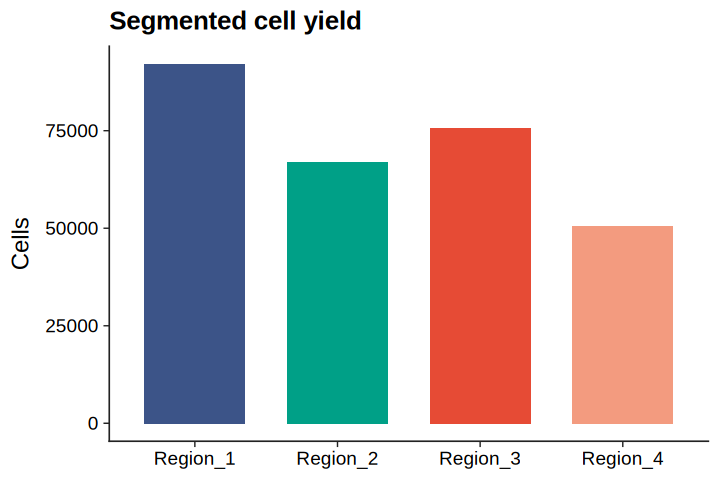

In [10]:
slide_plots$cell_yield

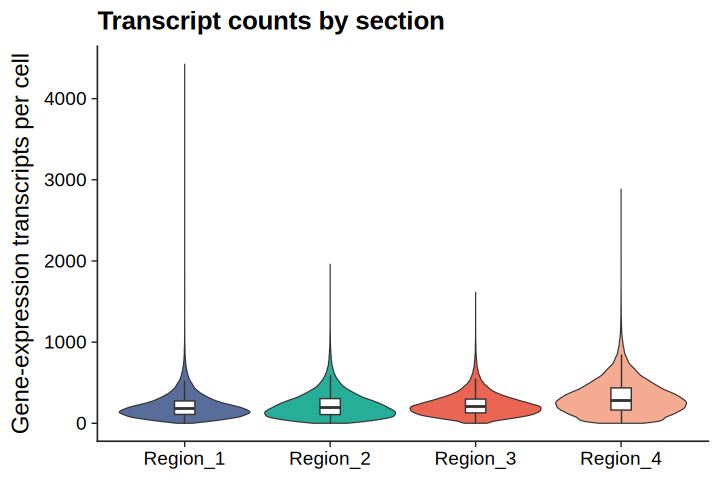

In [11]:
slide_plots$counts

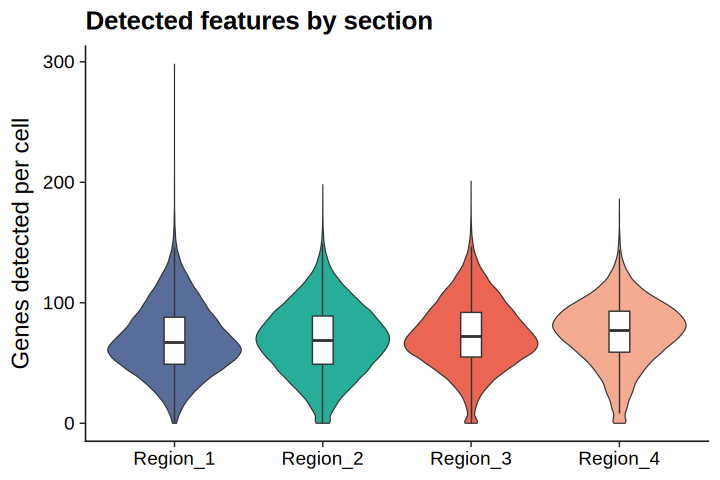

In [12]:
slide_plots$features

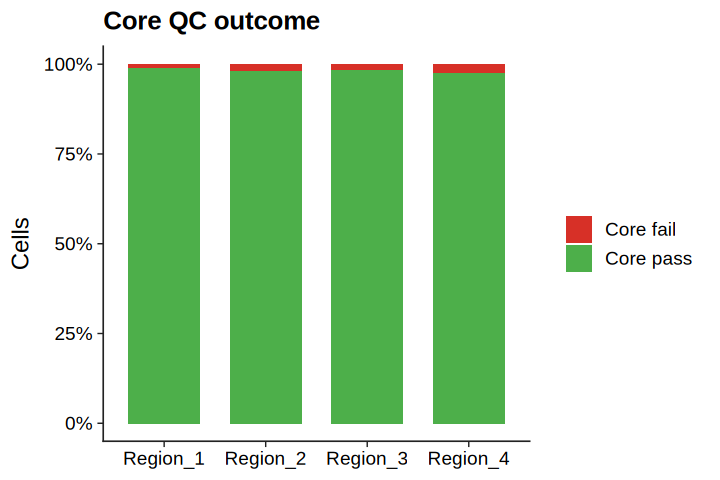

In [13]:
slide_plots$review

In [15]:
options(repr.plot.width=11, repr.plot.height=5)

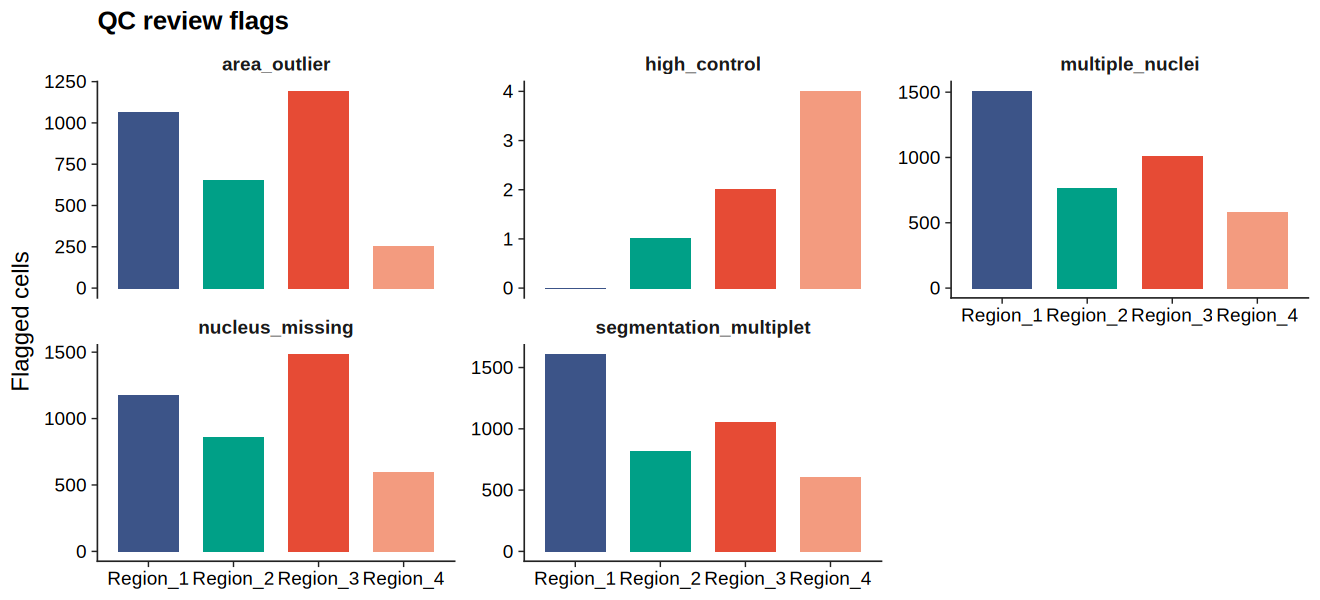

In [16]:
slide_plots$flags

In [17]:
options(repr.plot.width=8, repr.plot.height=5)

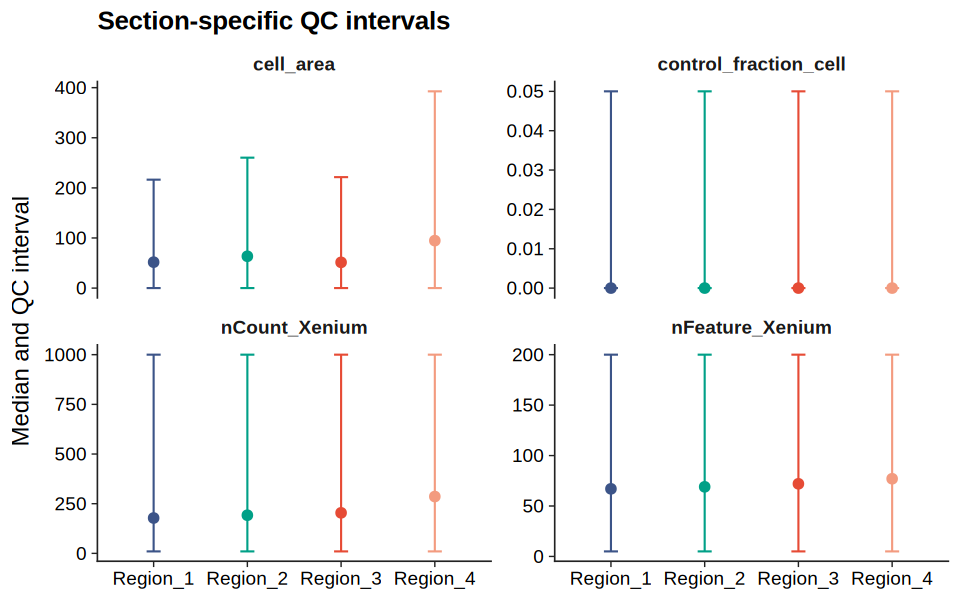

In [18]:
print(slide_plots$thresholds)

## Next steps

Use full-HPC evidence for the final initial-QC decision. With two mice, mouse and section comparisons are descriptive. Only after these gates pass should Region 3 be built as the anchor, Regions 1-2 be tested for admission, and Region 4 be handled as mapping-only sensitivity data.
